In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import pandas as pd
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [23]:
path = kagglehub.dataset_download(
    "nehalbirla/vehicle-dataset-from-cardekho"
)
ogdf = pd.read_csv(f"{path}/CAR DETAILS FROM CAR DEKHO.csv")
df = ogdf.copy()
third = int(len(df)/3)
#dff is for part f, the first third has been removed as it is the test data
dff = df.iloc[2*third:].copy()
# df.head()

# Dataset 1 - Vehicle dataset
by John Lopes

## Description

"This dataset contains information about used cars.
This data can be used for a lot of purposes such as price prediction to exemplify the use of linear regression in Machine Learning."

key features:
1. name
2. year
3. selling_price
4. km_driven
5. fuel
6. seller_type
7. transmission
8. Owner

## Code

## a)

In [ ]:
#wrong indices
indiciesMask = []

#look up
transmissionValues = ["Automatic", "Manual"]
transmissionInvalid = df.loc[~df["transmission"].isin(transmissionValues)].index.tolist()
indiciesMask.extend(transmissionInvalid)

fuelValues = ["Diesel", "Petrol", "CNG", "LPG", "Electric"]
fuelInvalid = df.loc[~df["fuel"].isin(fuelValues)].index.tolist()
indiciesMask.extend(fuelInvalid)

In [ ]:
#presence
nullMask = df.isnull().any(axis=1)
emptyMask = (df == '').any(axis=1)

emptyRows = df[nullMask | emptyMask]
emptyIndices = emptyRows.index.tolist()
indiciesMask.extend(emptyIndices)

In [ ]:
df = df.drop(indiciesMask, axis="index")

## b)

In [24]:
#did not encode the name column due to unique values
dfEncoded = pd.get_dummies(df.copy(), columns=['fuel', 'transmission', 'owner', 'seller_type'], drop_first=False)
dfEncoded.head()
#print(df["fuel"])
#print(dfEncoded["fuel_Diesel"])

,name,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer
0,Maruti 800 AC,2007,60000,70000,False,False,False,False,True,False,True,True,False,False,False,False,False,True,False
1,Maruti Wagon R LXI Minor,2007,135000,50000,False,False,False,False,True,False,True,True,False,False,False,False,False,True,False
2,Hyundai Verna 1.6 SX,2012,600000,100000,False,True,False,False,False,False,True,True,False,False,False,False,False,True,False
3,Datsun RediGO T Option,2017,250000,46000,False,False,False,False,True,False,True,True,False,False,False,False,False,True,False
4,Honda Amaze VX i-DTEC,2014,450000,141000,False,True,False,False,False,False,True,False,False,True,False,False,False,True,False


## c)

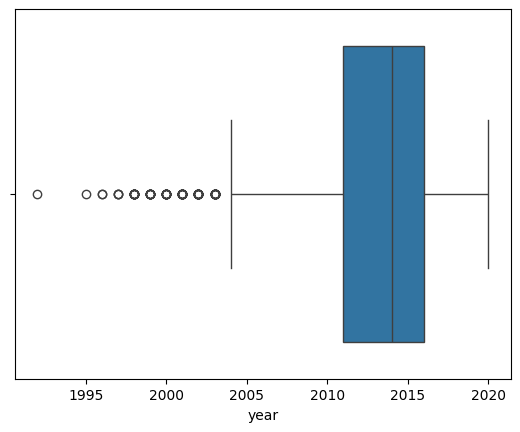

In [25]:
yearPlot = sns.boxplot(df,x="year")

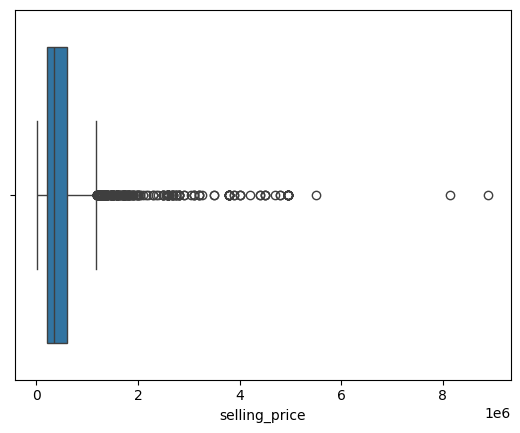

In [26]:
sellingPrice = sns.boxplot(df,x="selling_price")

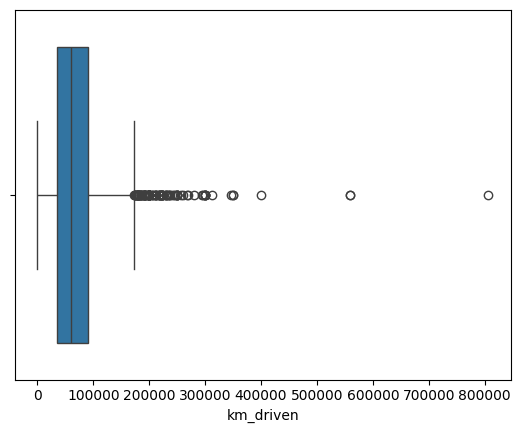

In [27]:
kmDriven = sns.boxplot(df,x="km_driven")

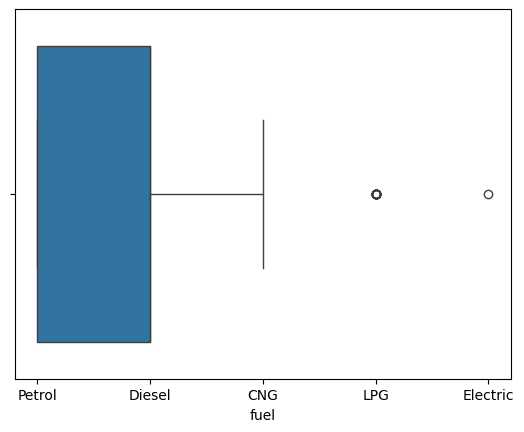

In [28]:
fuelPlot = sns.boxplot(df,x="fuel")

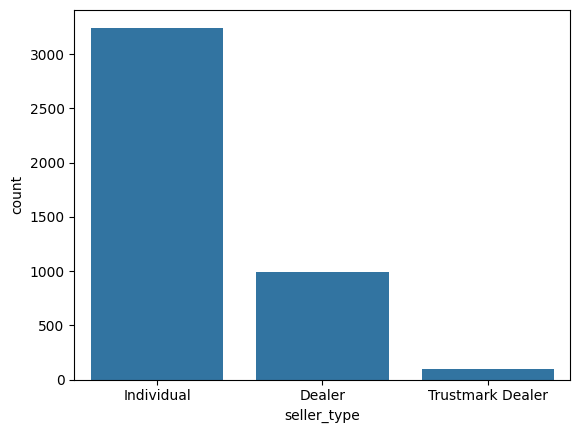

In [29]:
sellerPlot = sns.countplot(df,x="seller_type")

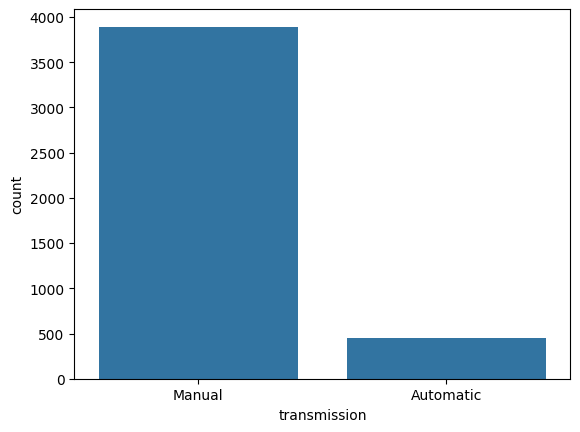

In [30]:
transmissionPlot = sns.countplot(df,x="transmission")

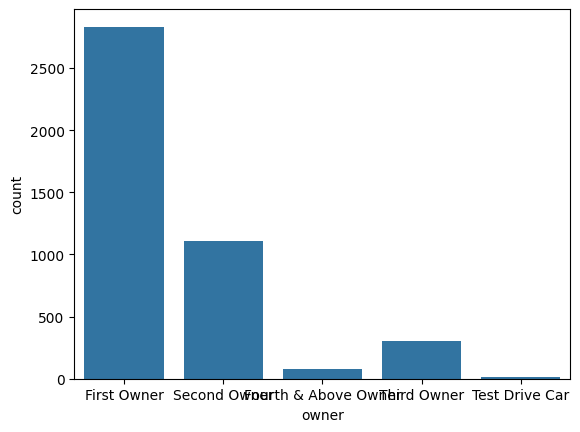

In [31]:
ownerPlot = sns.countplot(df,x="owner")

In [32]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

cols = [col for col in dfEncoded.columns if col not in ['name']]
dfEncoded['lof_label'] = lof.fit_predict(dfEncoded[cols])
dfEncoded['lof_score'] = lof.negative_outlier_factor_

dfEncoded[dfEncoded['lof_label'] == -1].head()

,name,year,selling_price,km_driven,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,transmission_Automatic,...,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,lof_label,lof_score
32,Audi Q5 2.0 TDI,2011,1190000,175900,False,True,False,False,False,True,...,True,False,False,False,False,True,False,False,-1,-1.727948
56,Hyundai i20 Sportz 1.4 CRDi,2018,750000,29000,False,True,False,False,False,False,...,True,False,False,False,False,True,False,False,-1,-1.764458
57,Maruti Omni Maruti Omni MPI STD BSIII 5-STR W/...,2018,310000,28000,False,False,False,False,True,False,...,True,False,False,False,False,True,False,False,-1,-1.647467
69,Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII,2010,280000,350000,False,True,False,False,False,False,...,False,False,True,False,False,False,True,False,-1,-1.669708
70,Toyota Corolla Altis Diesel D4DG,2011,350000,230000,False,True,False,False,False,False,...,True,False,False,False,False,False,True,False,-1,-1.487753


In [33]:
print(dfEncoded[dfEncoded["lof_label"]==-1])
#removing outliers
dfEncoded = dfEncoded[dfEncoded["lof_label"]!=-1]
print(dfEncoded[dfEncoded["lof_label"]==-1])
#dfEncoded.head()

                                                   name  year  selling_price  \
32                                      Audi Q5 2.0 TDI  2011        1190000   
56                          Hyundai i20 Sportz 1.4 CRDi  2018         750000   
57    Maruti Omni Maruti Omni MPI STD BSIII 5-STR W/...  2018         310000   
69        Chevrolet Tavera Neo LS B3 - 7(C) seats BSIII  2010         280000   
70                     Toyota Corolla Altis Diesel D4DG  2011         350000   
...                                                 ...   ...            ...   
4282                            Maruti Wagon R LX Minor  2013         290000   
4294                          Mahindra XUV500 AT W8 FWD  2015         740000   
4326                                 Honda City 1.5 GXI  2005          65000   
4331               Ford EcoSport 1.5 TDCi Titanium BSIV  2015         530000   
4334       Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV  2012         600000   

      km_driven  fuel_CNG  fuel_Diesel 

## d) - must fix still

coef: [56355.13376304]
intercept: -112946013.87252672
R² train: 0.19352818822559414
R² test : 0.1627607602479102


Text(0.5, 1.0, 'Linear regression year vs selling_price')

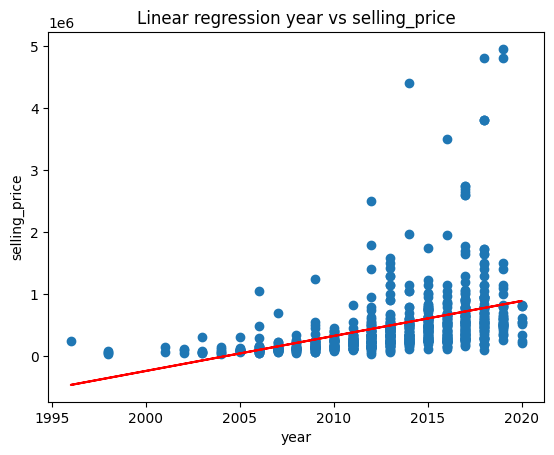

In [ ]:
x = dfEncoded[['year']]
y = dfEncoded['selling_price']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(x_train, y_train)

#print('coef:', model.coef_)
#print('intercept:', model.intercept_)
#print('R² train:', model.score(x_train, y_train))
#print('R² test :', model.score(x_test, y_test))

predictions = model.predict(x_test)
plt.scatter(x_test, y_test)
plt.plot(x_test, predictions, color='red')
plt.xlabel('year')
plt.ylabel('selling_price')
plt.title('Linear regression year vs selling_price')

## e)

In [48]:
df['selling_price_year'] = df['selling_price'].astype(str) + '_' + df['year'].astype(str)

df[['selling_price', 'year', 'selling_price_year']].head()

,selling_price,year,selling_price_year
0,60000,2007,60000_2007
1,135000,2007,135000_2007
2,600000,2012,600000_2012
3,250000,2017,250000_2017
4,450000,2014,450000_2014


In [36]:
df["transmission_fuel"] = df["transmission"] + '_' + df["fuel"]

df[["transmission", "fuel", "transmission_fuel"]].head()

,transmission,fuel,transmission_fuel
0,Manual,Petrol,Manual_Petrol
1,Manual,Petrol,Manual_Petrol
2,Manual,Diesel,Manual_Diesel
3,Manual,Petrol,Manual_Petrol
4,Manual,Diesel,Manual_Diesel


## f)

In [37]:
third = int(len(dff)/3)
subset1 = dff.iloc[:third]
subset2 = dff.iloc[third:2*third]
#subset1.head()
#subset2.head()

coef: [49114.06526663]
intercept: -98392945.50403967
R² train: 0.14815689241381236
R² test : 0.29993725667689364


Text(0.5, 1.0, 'Linear regression fit on year vs selling_price')

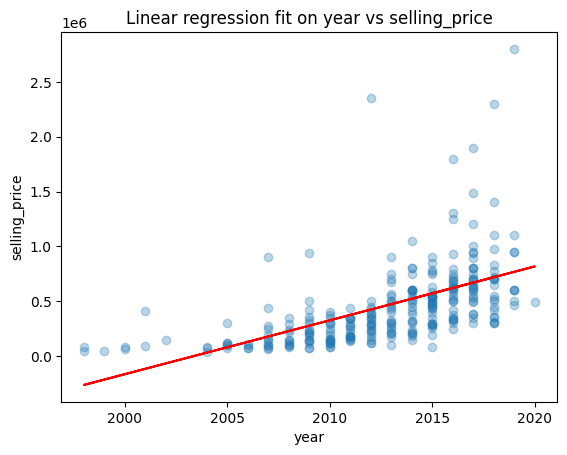

In [ ]:
#rmse selected
dffEncoded = pd.get_dummies(dff.copy(), columns=['fuel', 'transmission', 'owner', 'seller_type'], drop_first=False)
cols = [col for col in dffEncoded.columns if col not in ['name']]
dffEncoded['lof_label'] = lof.fit_predict(dffEncoded[cols])
dffEncoded['lof_score'] = lof.negative_outlier_factor_

x = dffEncoded[['year']]
y = dffEncoded['selling_price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(x_train, y_train)

print('coef:', model.coef_)
print('intercept:', model.intercept_)
print('R² train:', model.score(x_train, y_train))
print('R² test :', model.score(x_test, y_test))

predictions = model.predict(x_test)
plt.scatter(x_test, y_test)
plt.plot(x_test, predictions, color='red')
plt.xlabel('year')
plt.ylabel('selling_price')
plt.title('Linear regression year vs selling_price')

In [39]:


# features and target already defined above
# x = dfEncoded[['year']]   # or whatever feature set you want to evaluate
# y = dfEncoded['selling_price']

scores = cross_val_score(model, x, y, cv=4)     # or 'neg_mean_squared_error', etc.

print("R² scores per fold:", scores)
print("mean R²:", scores.mean())

R² scores per fold: [0.20359812 0.21531072 0.08465282 0.21676981]
mean R²: 0.18008286976439486


coef: [41918.84228222]
intercept: -83951109.20402351
R² train: 0.3161703550556272
R² test : 0.31865218074311397


Text(0.5, 1.0, 'Linear regression fit on year vs selling_price')

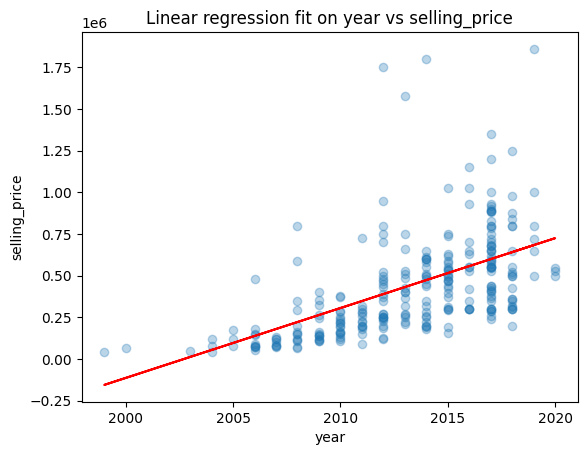

In [ ]:
dffEncoded = pd.get_dummies(dff.copy(), columns=['fuel', 'transmission', 'owner', 'seller_type'], drop_first=False)
cols = [col for col in dffEncoded.columns if col not in ['name']]
dffEncoded['lof_label'] = lof.fit_predict(dffEncoded[cols])
dffEncoded['lof_score'] = lof.negative_outlier_factor_
dffEncoded = dffEncoded[dffEncoded["lof_label"]!=-1]

x = dffEncoded[['year']]
y = dffEncoded['selling_price']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression().fit(x_train, y_train)

print('coef:', model.coef_)
print('intercept:', model.intercept_)
print('R² train:', model.score(x_train, y_train))
print('R² test :', model.score(x_test, y_test))

predictions = model.predict(x_test)
plt.scatter(x_test, y_test)
plt.plot(x_test, predictions, color='red')
plt.xlabel('year')
plt.ylabel('selling_price')
plt.title('Linear regression year vs selling_price')

In [41]:
scores = cross_val_score(model, x, y, cv=4)     # or 'neg_mean_squared_error', etc.

print("R² scores per fold:", scores)
print("mean R²:", scores.mean())

R² scores per fold: [0.31486941 0.31812358 0.25693581 0.34435674]
mean R²: 0.3085713857977985


## g)

## References

https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html 

https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html

https://www.geeksforgeeks.org/machine-learning/python-linear-regression-using-sklearn/